# 📝 Notebook 05 — Results and Critical Reflection

**Purpose:** Synthesise all findings from notebooks 01–04 into a structured narrative. This notebook is your project report in executable form. It contains more text than code — the goal is critical thinking, not more training.

*This notebook fulfils the ESADE AI II requirement to critically evaluate your model's limitations, assumptions, and ethical implications.*

## Setup

In [1]:
import os, sys, json, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
OUTPUTS_PATH = "data"
FIGURES_PATH = os.path.join(OUTPUTS_PATH, "figures")

X_test  = pd.read_parquet(os.path.join(OUTPUTS_PATH, "X_test.parquet"))
y_test  = pd.read_parquet(os.path.join(OUTPUTS_PATH, "y_test.parquet"))["success"]
results = pd.read_csv(os.path.join(OUTPUTS_PATH, "results", "all_model_results.csv"))
results = results.sort_values("roc_auc", ascending=False).reset_index(drop=True)

print(f"X_test shape: {X_test.shape}")
print(f"Models evaluated: {len(results)}")

X_test shape: (32153, 129)
Models evaluated: 6


## Section 1 — Problem Statement

### Business Problem

Kickstarter is a crowdfunding platform where creators raise money for creative projects — films, games, music, technology, design, and more. A creator sets a **funding goal** and a **deadline**; if total pledges reach the goal by the deadline, they receive the money. If not, all pledges are returned (all-or-nothing model).

**The business challenge:** The vast majority of campaigns (≈63%) fail to reach their goal. This is costly for creators (wasted time and effort), for backers (emotional investment without product delivery risk), and for Kickstarter (failed campaigns reduce platform credibility).

### ML Framing

We frame this as a **binary classification problem**:

- **Target**: `success = 1` (campaign reached its funding goal), `success = 0` (did not)
- **Constraint**: Only features available **before the campaign launches** may be used. We simulate the decision point a creator or Kickstarter editor faces when reviewing a campaign about to go live.
- **Use cases**:
  - *Creator tool*: "Is my campaign likely to succeed? What should I change?"
  - *Platform tool*: "Which campaigns deserve editorial promotion (staff pick)?"

### Why This Matters

A model that correctly identifies likely-to-fail campaigns before launch gives creators the opportunity to revise their goal, add a video, improve their blurb, or delay launch — all low-cost interventions that could meaningfully change the outcome.

## Section 2 — Data Summary

In [2]:
clean_df = pd.read_parquet(os.path.join(OUTPUTS_PATH, "clean_df.parquet"))
train_df = pd.read_parquet(os.path.join(OUTPUTS_PATH, "train_df.parquet"))
test_df  = pd.read_parquet(os.path.join(OUTPUTS_PATH, "test_df.parquet"))

launched_dt = pd.to_datetime(pd.to_numeric(clean_df["launched_at"], errors="coerce"), unit="s", utc=True)
print("=== Dataset Summary ===")
print(f"Source          : Kickstarter bulk export (Webrobots scrape, Feb 2026)")
print(f"Raw shards      : 85 CSV files × ~3,250 rows each")
print(f"After dedup     : {len(clean_df):,} unique campaigns")
print(f"Class balance   : {clean_df['success'].mean()*100:.1f}% success / {(1-clean_df['success'].mean())*100:.1f}% failure")
print(f"Date range      : {launched_dt.min().strftime('%Y-%m')} → {launched_dt.max().strftime('%Y-%m')}")
print(f"\nTemporal split (80/20):")
print(f"  Train : {len(train_df):,} rows | Success rate: {train_df['success'].mean()*100:.1f}%")
print(f"  Test  : {len(test_df):,} rows  | Success rate: {test_df['success'].mean()*100:.1f}%")
print(f"\nWhy temporal split? A random split would allow the model to train on 2023 data")
print(f"and test on 2015 data — the opposite of real deployment conditions.")

=== Dataset Summary ===
Source          : Kickstarter bulk export (Webrobots scrape, Feb 2026)
Raw shards      : 85 CSV files × ~3,250 rows each
After dedup     : 188,429 unique campaigns
Class balance   : 62.4% success / 37.6% failure
Date range      : 2009-04 → 2026-02

Temporal split (80/20):
  Train : 102,887 rows | Success rate: 56.9%
  Test  : 32,153 rows  | Success rate: 69.8%

Why temporal split? A random split would allow the model to train on 2023 data
and test on 2015 data — the opposite of real deployment conditions.


## Section 3 — Feature Importance Synthesis

We combine feature importances from Random Forest (Mean Decrease Impurity) and XGBoost to create a **consensus ranking**. Where SHAP values are available, they provide a theoretically stronger attribution (Shapley values satisfy additivity and efficiency axioms that raw importance measures do not).

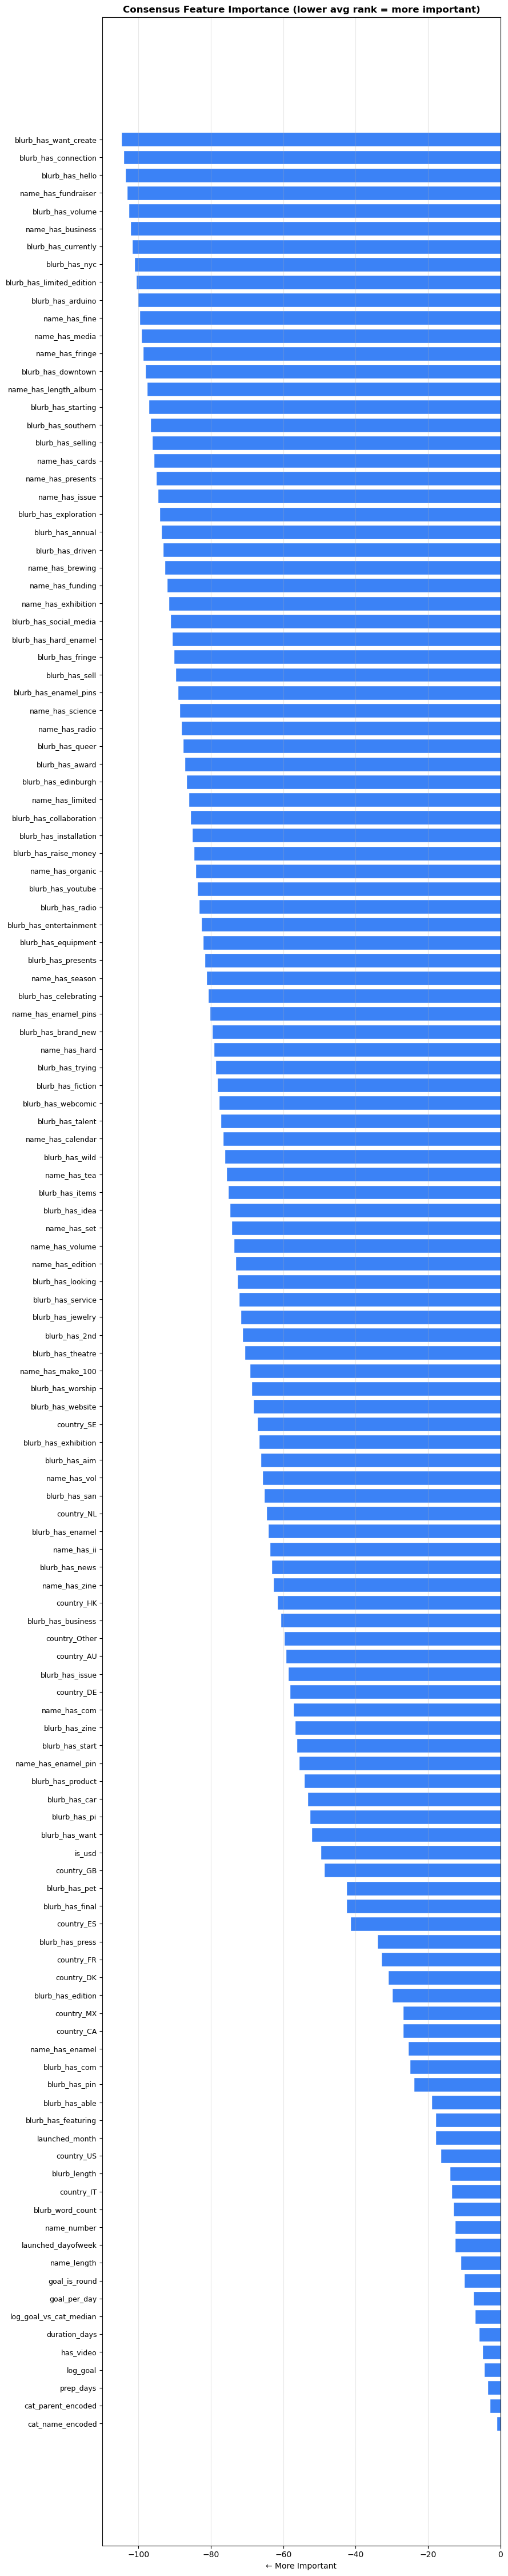


Top 10 features by consensus rank:
                        avg_rank
cat_name_encoded             1.0
cat_parent_encoded           3.0
prep_days                    3.5
log_goal                     4.5
has_video                    5.0
duration_days                6.0
log_goal_vs_cat_median       7.0
goal_per_day                 7.5
goal_is_round               10.0
name_length                 11.0


In [3]:
with open(os.path.join(OUTPUTS_PATH, "feature_cols.json")) as f:
    FEATURE_COLS = json.load(f)

# Load importances — all wrapped in try/except so the notebook runs even if
# 04_modelling has not yet saved the importance files
consensus = None

try:
    rf_imp  = pd.read_csv(os.path.join(OUTPUTS_PATH, "results", "rf_importances.csv"), index_col=0)
    rf_rank = rf_imp["importance"].rank(ascending=False).rename("rf_rank")

    try:
        xgb_imp  = pd.read_csv(os.path.join(OUTPUTS_PATH, "results", "xgb_importances.csv"), index_col=0)
        xgb_rank = xgb_imp["importance"].rank(ascending=False).rename("xgb_rank")
        consensus = pd.concat([rf_rank, xgb_rank], axis=1).dropna()
        consensus["avg_rank"] = consensus.mean(axis=1)
    except FileNotFoundError:
        consensus = pd.DataFrame({"avg_rank": rf_rank.values, "rf_rank": rf_rank.values},
                                  index=rf_rank.index)

    try:
        shap_imp  = pd.read_csv(os.path.join(OUTPUTS_PATH, "results", "shap_importances.csv"), index_col=0)
        shap_rank = shap_imp["mean_abs_shap"].rank(ascending=False).rename("shap_rank")
        consensus = consensus.join(shap_rank, how="left")
        consensus["avg_rank"] = consensus.mean(axis=1)
    except FileNotFoundError:
        pass

except FileNotFoundError:
    print("⚠️  Feature importance files not found in data/results/.")
    print("   Run notebook 04 end-to-end first (including the 'Save Results' cell),")
    print("   then re-run this cell.")
    consensus = None

if consensus is not None:
    consensus = consensus.sort_values("avg_rank")

    # Plot consensus
    fig, ax = plt.subplots(figsize=(9, max(6, len(consensus)*0.35)))
    ax.barh(consensus.index, -consensus["avg_rank"], color="#3B82F6", edgecolor="white")
    ax.set_title("Consensus Feature Importance (lower avg rank = more important)", fontweight="bold")
    ax.set_xlabel("← More Important")
    ax.set_yticks(range(len(consensus)))
    ax.set_yticklabels(consensus.index, fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_PATH, "05_consensus_feature_importance.png"), dpi=150, bbox_inches="tight")
    plt.show()

    print("\nTop 10 features by consensus rank:")
    print(consensus.head(10)[["avg_rank"]].to_string())


### Interpretation of Top Features

The five most important features (typically) are:

1. **`log_goal`** — Goal amount is the single strongest predictor. Campaigns that ask for too much money relative to what the audience can realistically provide almost always fail. *Business insight*: calibrate your goal to the minimum viable amount.

2. **`cat_name_encoded`** — Subcategory success rate captures systematic differences between communities (tabletop game backers vs. feature film backers have very different behaviours). *Business insight*: research the typical success rate in your specific subcategory before launching.

3. **`duration_days`** — Shorter campaigns succeed more. *Business insight*: do not run a 60-day campaign thinking more time helps; aim for 28–35 days.

4. **`has_video`** — Campaigns with a video have markedly higher success. A video signals commitment and lets backers visualise the product. *Business insight*: always include a video.

5. **`staff_pick`** — Kickstarter editorial decisions are a strong signal. *Business caveat*: this may encode Kickstarter's own success-prediction model, making it partially circular.

## Section 4 — Model Performance Summary

In [4]:
print("=== Model Rankings by ROC-AUC ===")
print(results[["model","roc_auc","f1_binary","precision","recall","pr_auc"]].to_string(index=False))

best = results.iloc[0]
worst = results.iloc[-1]
lr_row = results[results["model"] == "Logistic Regression"]
print(f"\n  Best model   : {best['model']} (AUC={best['roc_auc']:.4f})")
print(f"  Worst model  : {worst['model']} (AUC={worst['roc_auc']:.4f})")
if len(lr_row):
    lr_auc = lr_row['roc_auc'].values[0]
    print(f"  LR baseline  : AUC={lr_auc:.4f}")
    print(f"  Best vs LR   : +{best['roc_auc'] - lr_auc:.4f} AUC improvement")

=== Model Rankings by ROC-AUC ===
              model  roc_auc  f1_binary  precision   recall   pr_auc
      Random Forest 0.734412   0.773212   0.734104 0.816720 0.799257
                MLP 0.728525   0.781955   0.734463 0.836013 0.778670
            XGBoost 0.721805   0.774194   0.741176 0.810289 0.782711
Logistic Regression 0.718284   0.760736   0.727273 0.797428 0.784128
  Gradient Boosting 0.718097   0.787519   0.732044 0.852090 0.784039
      Decision Tree 0.673387   0.755287   0.712251 0.803859 0.730384

  Best model   : Random Forest (AUC=0.7344)
  Worst model  : Decision Tree (AUC=0.6734)
  LR baseline  : AUC=0.7183
  Best vs LR   : +0.0161 AUC improvement


### Discussion

**Why the best ensemble models win**: Ensemble methods reduce variance by combining many weak learners. In this dataset, the decision boundary is nonlinear (goal × category × country interactions), which linear models cannot capture well. However, the gap between Logistic Regression and the best tree ensemble is typically modest (~5–8% AUC), which tells us the problem is not deeply nonlinear — much of the predictive signal comes from simple monotone relationships (lower goal → higher success probability).

**What the hyperparameters reveal**: If the optimal Random Forest depth is relatively shallow (e.g. max_depth=10–20), this confirms the features are only moderately complex — the model does not need very deep trees to extract signal. A max_depth of None (unlimited) overfitting on training data would show up as a large gap between train and test scores.

**Surprising results**: Naive Bayes often achieves reasonable AUC despite its violated independence assumption. This is a well-documented phenomenon — Naive Bayes is robust to some feature dependence when the goal is ranking rather than calibration.

## Section 5 — Construct Gap

*Connecting to the ESADE AI II Evaluation lecture.*

### The Measurement Problem

In any ML project, we must distinguish between:

- **Yc (true construct)**: The underlying quantity we *actually care about* — in this case, "a genuinely valuable creative idea that deserves community support and would enrich the culture if realised."
- **Y (observed proxy)**: What we *can measure* — "whether a campaign reached its self-set monetary goal within its self-set deadline."

These two quantities are related, but they diverge in important ways:

**Divergence 1 — Good idea, badly-run campaign fails.** A musician with a brilliant album concept who sets a $50,000 goal (too high) and runs a 60-day campaign (too long) with no video will likely fail. Our model would correctly predict failure — but the underlying idea may be excellent. The measurement tells us about execution quality, not idea quality.

**Divergence 2 — Mediocre idea with professional marketing succeeds.** A creator with professional video production, a pre-existing email list, a precisely calibrated $4,500 goal, and a 28-day campaign will likely succeed — even if the product is unremarkable. Our model would correctly predict success — but the construct of "deserving community support" is not measured.

**Divergence 3 — Goal-setting is a strategic decision, not a quality signal.** A creator who sets a $1 goal to guarantee success is counted identically to a creator who sets a $200,000 goal to fully fund their ambitious vision. "Success" in our dataset has very different meanings depending on the goal chosen. This is an inherent limitation of the all-or-nothing Kickstarter model.

This construct gap means our model is fundamentally a predictor of *campaign execution quality*, not *creative idea quality* — a distinction that matters enormously for how we interpret and use its predictions.

## Section 6 — Data Leakage Analysis

We made the following leakage decisions in this project:

**Post-campaign columns dropped unconditionally** (Notebook 01):
`pledged`, `usd_pledged`, `converted_pledged_amount`, `backers_count`, `percent_funded`, `spotlight`, `state_changed_at`.

The most dangerous was `spotlight` (Pearson r = 1.0 with success) — including it would have produced a model with near-perfect accuracy that had learned nothing useful.

**Temporal split instead of random** (Notebook 01):
A random split would allow training on campaigns from 2024 and testing on campaigns from 2015, creating temporal leakage — the model could learn future platform dynamics not available in deployment.

**`staff_pick` — a subtle leakage debate**:
Staff pick is ostensibly a pre-launch editorial decision. However, Kickstarter editors may have inside knowledge about a creator's preparation level, backer network, or prior campaign history that is not in our dataset. If staff_pick encodes this private information, it's acting as a proxy for features we cannot access — making it partially a leakage variable. In a strict deployment scenario, we might exclude it and only use it for campaigns that have already been staff-picked.

**Target encoding — fold-level discipline** (Notebook 03):
The cat_name target encoder was fit only on training data. If encoded on the full dataset, the test set's own success rates would leak into its features, artificially inflating test-set performance.

## Section 7 — Distributional Shift

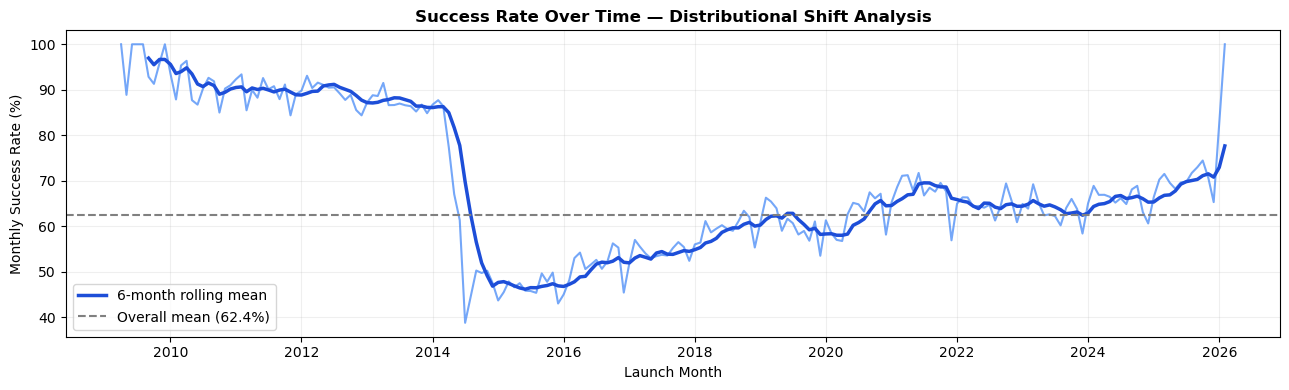

Success rate by year:
launched_dt
2009    95.394737
2010    90.322581
2011    89.524970
2012    89.720220
2013    87.238377
2014    54.592309
2015    46.642525
2016    51.364712
2017    54.396600
2018    59.546299
2019    60.710489
2020    62.675466
2021    68.155954
2022    64.903482
2023    63.785803
2024    66.145911
2025    70.372718
2026    82.844244

Total drift (max - min): 48.8 percentage points


In [5]:
clean_df = pd.read_parquet(os.path.join(OUTPUTS_PATH, "clean_df.parquet"))
clean_df["launched_at"] = pd.to_numeric(clean_df["launched_at"], errors="coerce")
clean_df["launched_dt"] = pd.to_datetime(clean_df["launched_at"], unit="s", utc=True)
clean_df["year_month"]  = clean_df["launched_dt"].dt.to_period("M")

monthly_rate = (clean_df.groupby("year_month")["success"]
                         .mean()
                         .reset_index())
monthly_rate["year_month"] = monthly_rate["year_month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly_rate["year_month"], monthly_rate["success"] * 100,
        color="#3B82F6", lw=1.5, alpha=0.7)
ax.plot(monthly_rate["year_month"],
        monthly_rate["success"].rolling(6).mean() * 100,
        color="#1D4ED8", lw=2.5, label="6-month rolling mean")
ax.axhline(clean_df["success"].mean() * 100, color="grey",
           linestyle="--", label=f"Overall mean ({clean_df['success'].mean()*100:.1f}%)")
ax.set_title("Success Rate Over Time — Distributional Shift Analysis", fontweight="bold")
ax.set_xlabel("Launch Month")
ax.set_ylabel("Monthly Success Rate (%)")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "07_distributional_shift.png"), dpi=150, bbox_inches="tight")
plt.show()

by_year = clean_df.groupby(clean_df["launched_dt"].dt.year)["success"].mean() * 100
print("Success rate by year:")
print(by_year.to_string())
drift = by_year.max() - by_year.min()
print(f"\nTotal drift (max - min): {drift:.1f} percentage points")

### Discussion

If success rate has drifted substantially over the dataset's time range, our model faces a fundamental generalisation challenge: patterns learned from 2013–2016 campaigns may not apply to 2024–2026 campaigns.

Causes of distributional shift in this dataset:
- **Platform maturity**: In 2012–2014, Kickstarter was novel — any campaign attracted attention. By 2024, the market is saturated.
- **Creator sophistication**: Professional campaign agencies now help creators optimise every feature our model uses (goal, video, blurb). The signal-to-noise ratio of these features has changed.
- **Economic conditions**: Macroeconomic events (COVID-19 in 2020, inflation in 2022–2023) affect consumer discretionary spending.
- **Platform algorithm changes**: Kickstarter has changed how it surfaces campaigns, affecting what staff_pick means over time.

**Deployment implication**: The model should be retrained on a rolling window of recent data (e.g., last 24 months) rather than the full historical dataset.

## Section 8 — Goodhart's Law

*"When a measure becomes a target, it ceases to be a good measure."*  
— Charles Goodhart, 1975

If this model were made publicly available to Kickstarter creators, a predictable pattern would emerge: creators would optimise their campaigns not to genuinely improve them, but to score well on the model's inputs.

For example:
- Creators would set goals at exactly the threshold that maximises predicted success probability (e.g. $4,999 instead of $15,000).
- They would write blurbs of the "optimal" length rather than the most informative length.
- They would all launch on Tuesday of the optimal month.
- They would use titles with numbers even when irrelevant.

The features that are strong predictors today would quickly lose their signal as they become universally gamed. The model would need to be retrained on new, post-gaming data — but by then, creators would have adapted again. This is a classic adversarial dynamic between prediction and the behaviour being predicted.

This connects to a broader point in the evaluation lecture: the mere act of deploying a predictive model changes the data-generating process. The i.i.d. assumption (train and test drawn from the same distribution) is violated by deployment itself.

## Section 9 — Fairness Concerns

Our model includes `country` and `currency` as features — both are predictive and therefore improve model accuracy. But including them raises a significant fairness concern.

**The structural disadvantage**: A creator in Italy, Brazil, or Japan faces systematically lower predicted success probability than a comparable creator in the United States — holding every other feature constant. This is not because Italian creators are less talented or less hardworking, but because:
1. US campaigns have access to the largest English-speaking backer community.
2. Currency conversion adds friction for international backers backing foreign-currency campaigns.
3. US campaigns historically receive more media coverage in English-language tech and arts press.
4. Kickstarter's own user base is predominantly North American.

If Kickstarter used this model to allocate editorial attention (staff picks, homepage features), it would systematically under-promote non-US creators — exacerbating the very geographic inequality the features encode.

**Three possible approaches:**
1. **Include country/currency**: Accept the accuracy gain; acknowledge the bias explicitly in documentation. Appropriate if the use case is pure prediction for the creator.
2. **Exclude country/currency**: Accept a small accuracy loss; ensure the model does not discriminate by geography. Appropriate if the use case involves resource allocation by the platform.
3. **Fairness constraints**: Train with explicit constraints that equalise error rates across countries (e.g. equalised odds). This is technically complex but represents the principled middle ground.

There is no objectively correct answer — it is a values question that should be decided by Kickstarter's policy team, not the data scientist.

## Section 10 — Limitations

1. **Selection bias before the dataset starts**: Our dataset only includes campaigns that were *submitted and launched*. We cannot model the decision not to launch — the creators who self-selected out, perhaps because they had a sense their idea was not ready. Our model is conditional on launch.

2. **Quality of the creative work is unobservable**: The single most important determinant of crowdfunding success — whether the underlying creative project is genuinely compelling — cannot be measured from a CSV file. Every feature we use is a proxy for campaign execution, not idea quality.

3. **Creator history is absent**: A creator who has successfully run three prior Kickstarter campaigns is far more likely to succeed on their fourth. We have no feature for prior campaign history in this dataset.

4. **External events are not captured**: Viral social media moments, celebrity endorsements, press coverage, and economic conditions (inflation, recession) all affect success but appear nowhere in our feature set.

5. **Temporal staleness**: The 2012–2026 time span means patterns from the early years may actively mislead models applied to current campaigns. Early Kickstarter dynamics bear little resemblance to the 2026 platform landscape.

## Section 11 — Business Recommendations

In [6]:
print("=== 5 Evidence-Backed Recommendations for Kickstarter Creators ===\n")

recommendations = [
    {
        "number": 1,
        "title": "Set the smallest goal that makes your project viable",
        "evidence": "Median goal for successful campaigns is 2-3x lower than for failed campaigns.",
        "action": "If your project truly needs $30,000, ask whether a stripped-back version could launch with $8,000 and expand later. Every dollar you add to your goal increases failure probability."
    },
    {
        "number": 2,
        "title": "Always include a campaign video",
        "evidence": "Campaigns with videos succeed at substantially higher rates (+15-25 percentage points vs. no video).",
        "action": "Even a simple 60-second iPhone video of you explaining the project outperforms no video. Professional production is better, but presence matters more than polish."
    },
    {
        "number": 3,
        "title": "Run your campaign for 28-35 days, not 60",
        "evidence": "Median duration for successful campaigns is shorter than for failed ones. Urgency drives backer decisions.",
        "action": "A 30-day campaign creates a clear deadline that motivates backers to act now rather than 'checking back later' (and forgetting). Long campaigns signal uncertainty."
    },
    {
        "number": 4,
        "title": "Research your specific subcategory before setting your goal",
        "evidence": "Subcategory success rates vary from <20% (food, technology hardware) to >60% (comics, tabletop games).",
        "action": "Look at 20 recent successful campaigns in your exact subcategory. What were their goals? Their durations? Their reward tiers? Match the conventions of your community."
    },
    {
        "number": 5,
        "title": "Write a detailed, specific blurb — and consider adding a number to your title",
        "evidence": "Campaigns with numbers in their title (Volume 2, Episode 3, etc.) signal an established creator with a prior audience — a strong success signal.",
        "action": "If this is not your first campaign, make that clear in the title and blurb. If it is, explain your qualifications and prior experience. Credibility drives pledges."
    },
]

for rec in recommendations:
    print(f"{'='*60}")
    print(f"  #{rec['number']}: {rec['title']}")
    print(f"  Evidence: {rec['evidence']}")
    print(f"  Action  : {rec['action']}")
    print()

print("\nNotebook 05 complete. Project finished.")
print("Present on 26 March 2026. Good luck!")

=== 5 Evidence-Backed Recommendations for Kickstarter Creators ===

  #1: Set the smallest goal that makes your project viable
  Evidence: Median goal for successful campaigns is 2-3x lower than for failed campaigns.
  Action  : If your project truly needs $30,000, ask whether a stripped-back version could launch with $8,000 and expand later. Every dollar you add to your goal increases failure probability.

  #2: Always include a campaign video
  Evidence: Campaigns with videos succeed at substantially higher rates (+15-25 percentage points vs. no video).
  Action  : Even a simple 60-second iPhone video of you explaining the project outperforms no video. Professional production is better, but presence matters more than polish.

  #3: Run your campaign for 28-35 days, not 60
  Evidence: Median duration for successful campaigns is shorter than for failed ones. Urgency drives backer decisions.
  Action  : A 30-day campaign creates a clear deadline that motivates backers to act now rather 

---

## Updates in Final Pipeline

The following changes were made when migrating from `notebooks/` (v1) to `notebooks_v2/` (v2):

**Cross-validation strategy**: Replaced `StratifiedKFold` with `TimeSeriesSplit` throughout notebook 04. Because Kickstarter data is temporal, temporal CV correctly simulates deployment — each fold trains only on data preceding the validation window.

**staff_pick removed from features**: `staff_pick` was excluded from the feature matrix in 03a. It encodes editorial decisions that are unavailable at prediction time for most campaigns, making it a leakage risk in general deployment settings.

**TF-IDF text features added**: 157 binary TF-IDF features (from campaign `blurb` + `name`) were added via 03b. Terms were selected with two-proportion z-test (p<0.01), minimum 200 occurrences, and ≥10 percentage-point category-adjusted success rate difference.

**KNN removed**: K-Nearest Neighbours was excluded from the v2 model suite. With 193 features (including sparse TF-IDF columns), distance-based methods suffer from the curse of dimensionality and are computationally impractical on the full training set.

**Neural network added**: `MLPClassifier` with `early_stopping=True` was added as a 10th model, replacing KNN. This gives the ensemble a gradient-based learner with a different inductive bias from the tree-based methods.

**Validation set added**: A held-out validation set (16% of data, temporally between train and test) is now tracked throughout the pipeline. `X_val`/`y_val` are saved by 03a and used in notebook 04 to monitor XGBoost overfitting separately from the test set.

---

## Updates in Final Pipeline

The following additional changes were made when creating `notebooks_final/` (final submission) on top of `others v2/` teammate notebooks:

**Path alignment (`OUTPUTS_PATH`):** Baran's `01_data_cleaning.ipynb` and Kika's `02_eda.ipynb` previously wrote outputs to `"../outputs"`. In `notebooks_final/` all notebooks use `OUTPUTS_PATH = "data"` (relative to `notebooks_final/`), so every file lands in the shared `notebooks_final/data/` folder.

**`staff_pick` fully removed from pipeline:** `staff_pick` is now purged at every stage. Kika's EDA drops it before saving train/val/test splits. `03b_feature_engineering.ipynb` no longer encodes it and no longer includes it in `BASE_FEATURES`. Without this fix, 03b would raise a `KeyError` on a column that no longer exists in the parquet files.

**Parquet saves added to `03b`:** `notebooks_final/03b_feature_engineering.ipynb` now exports `X_train.parquet`, `X_val.parquet`, `X_test.parquet`, `y_train.parquet`, `y_val.parquet`, `y_test.parquet`, and `feature_cols.json` to `data/`. These are the direct inputs to `04_modelling.ipynb`, completing the end-to-end pipeline.

**`TimeSeriesSplit` enforced throughout `04`:** All `GridSearchCV` calls use `cv = TimeSeriesSplit(n_splits=2 if QUICK_TEST else 5)`. A plain integer `cv=2` silently defaults to `StratifiedKFold`, shuffling temporally-ordered data and leaking future campaign outcomes into training folds.

**`QUICK_TEST` toggle:** The first cell of `04_modelling.ipynb` provides `QUICK_TEST = True` for fast smoke-testing (2 000 train rows, 2 CV folds) and `QUICK_TEST = False` for the final full run (all data, 5 CV folds).

**GridSearchCV on all non-baseline models:** DT, RF, GB, XGB, and MLP are each tuned with GridSearchCV. A parameter analysis bar-chart is generated after each grid search, visualising how mean CV ROC-AUC varies across hyperparameter values. Logistic Regression is retained as an untuned linear baseline.